In [2]:
#---Carga de datos---
import pandas as pd

df = pd.read_csv("data/libros_extraidos.csv")

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()


Filas: 1000, Columnas: 5


,Title,Price,Rating,Availability,Category
0,A Light in the Attic,Â£51.77,Three,In Stock,Poetry
1,Tipping the Velvet,Â£53.74,One,In Stock,Historical Fiction
2,Soumission,Â£50.10,One,In Stock,Fiction
3,Sharp Objects,Â£47.82,Four,In Stock,Mystery
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In Stock,History


===LIMPIEZA Y PROCESAMIENTO DE DATOS===

In [3]:
#---Verificar tipos de datos---
df.info()

#Todos deberían ser texto

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Title         1000 non-null   str  
 1   Price         1000 non-null   str  
 2   Rating        1000 non-null   str  
 3   Availability  1000 non-null   str  
 4   Category      1000 non-null   str  
dtypes: str(5)
memory usage: 39.2 KB


1000 Non-Null Count significa que no hay elementos vacíos
Se hará la revisión con código por razones plenamente didácticas

In [4]:
#---Limpieza de columna "Price"---

df["Price"] = df["Price"].str.extract(r"(\d+\.\d+)").astype(float)
df["Price"].describe()

count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: Price, dtype: float64

Todos los precios ahora son valores de tipo 'float', ya no hay símbolos inecesarios

In [5]:
#---Limpieza de columna "Rating"---

equivalencia_de_rating = {
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5,
}

df["Rating"]=df["Rating"].map(equivalencia_de_rating)

#Detección de datos mal igualados
print("Valores nulos generados al mapear Rating:", df["Rating"].isnull().sum())
df["Rating"] = df["Rating"].astype(int)
df["Rating"].value_counts().sort_index()

Valores nulos generados al mapear Rating: 0


Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

In [6]:
#---Valores nulos y duplicados---

print("Valores nulos por columna:")
print(df.isnull().sum())

#Detección y eliminación de duplicados
print("\nFilas completamente duplicadas:", df.duplicated().sum())
filas_antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
filas_despues = df.shape[0]

print(f"Filas antes: {filas_antes} | Filas después: {filas_despues}")

Valores nulos por columna:
Title           0
Price           0
Rating          0
Availability    0
Category        0
dtype: int64

Filas completamente duplicadas: 0
Filas antes: 1000 | Filas después: 1000


In [7]:
#---Revisión de información---
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   int64  
 3   Availability  1000 non-null   str    
 4   Category      1000 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 39.2 KB


,Title,Price,Rating,Availability,Category
0,A Light in the Attic,51.77,3,In Stock,Poetry
1,Tipping the Velvet,53.74,1,In Stock,Historical Fiction
2,Soumission,50.10,1,In Stock,Fiction
3,Sharp Objects,47.82,4,In Stock,Mystery
4,Sapiens: A Brief History of Humankind,54.23,5,In Stock,History


Se muestran valores de distintos tipos:
- Str (Title, Availability, Category)
- Int (Rating)
- Float (Price)

===ANÁLISIS EXPLORATORIO===

In [8]:
#---Configuración de librerías---

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

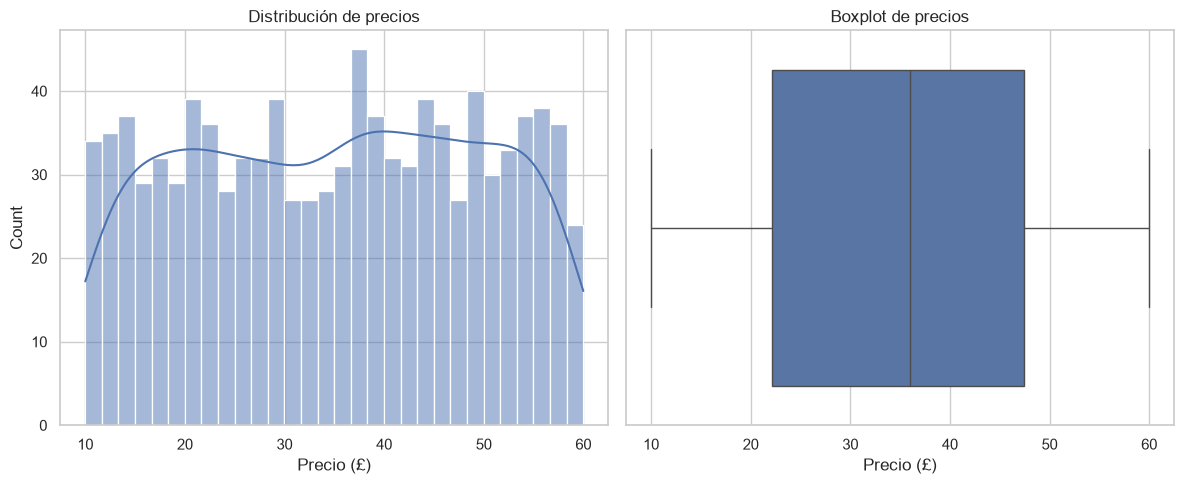

In [9]:
#---Distribución de precios---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Price"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribución de precios")
axes[0].set_xlabel("Precio (£)")

sns.boxplot(x=df["Price"], ax=axes[1])
axes[1].set_title("Boxplot de precios")
axes[1].set_xlabel("Precio (£)")

plt.tight_layout()
plt.show()

Los gráficos muestran la distribución de precios en general
- Pocos libros tienen de precio los extremos (10 o 60)
- Los datos son relativamente uniformes dentro de los límites
- Media: 35
- Mediana: 36 aprox

Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Name: count, dtype: int64


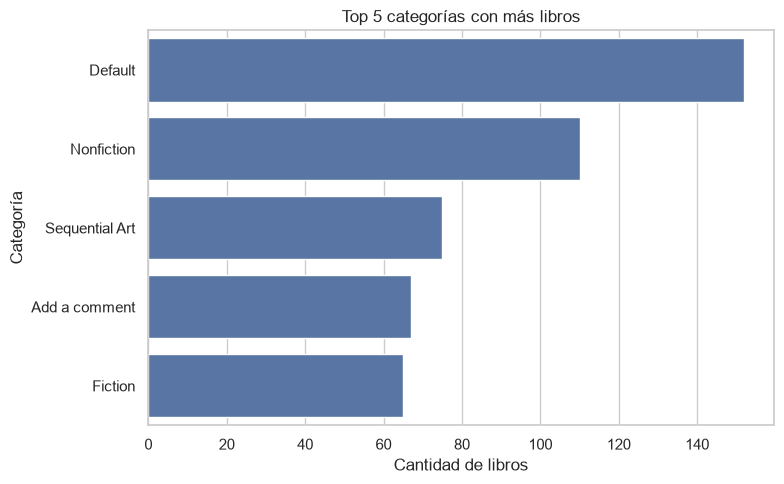

In [10]:
#---Top 5 categorías con más libros---

top5_categorias = df["Category"].value_counts().head(5)
print(top5_categorias)

plt.figure(figsize=(8, 5))
sns.barplot(x=top5_categorias.values, y=top5_categorias.index, orient="h")
plt.title("Top 5 categorías con más libros")
plt.xlabel("Cantidad de libros")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

In [17]:
#---Cantidad de libros con Rating 5 estrellas---

conteo_por_rating = (
    df["Rating"]
    .value_counts()
    .reindex([5, 4, 3, 2, 1])
    .reset_index()
)

conteo_por_rating.columns = ["Rating (estrellas)", "Cantidad de libros"]
conteo_por_rating

,Rating (estrellas),Cantidad de libros
0,5,196
1,4,179
2,3,203
3,2,196
4,1,226


In [16]:
#---Precio promedio y precio promedio por categoría---
precio_promedio_categoria = (
    df.groupby("Category")["Price"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

top_5_mas_caras = precio_promedio_categoria.head(5)
top_5_mas_baratas = precio_promedio_categoria.tail(5).sort_values()

tabla_precios_categoria = pd.concat(
    [top_5_mas_caras, top_5_mas_baratas],
    keys=["Más cara", "Más barata"]
).reset_index()

tabla_precios_categoria.columns = ["Grupo", "Categoría", "Precio Promedio (£)"]
tabla_precios_categoria


,Grupo,Categoría,Precio Promedio (£)
0,Más cara,Suspense,58.33
1,Más cara,Novels,54.81
2,Más cara,Politics,53.61
3,Más cara,Health,51.45
4,Más cara,New Adult,46.38
5,Más barata,Crime,10.97
6,Más barata,Academic,13.12
7,Más barata,Adult Fiction,15.36
8,Más barata,Paranormal,15.40
9,Más barata,Erotica,19.19


In [15]:
total_libros = df.shape[0]
precio_promedio_general = df["Price"].mean().round(2)

print(f"Cantidad total de libros en el catálogo: {total_libros}")
print(f"Precio promedio general: £{precio_promedio_general}")

Cantidad total de libros en el catálogo: 1000
Precio promedio general: £35.07


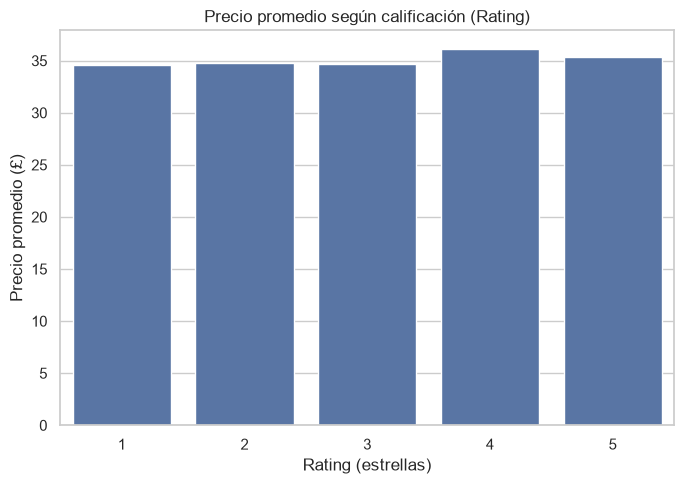

In [12]:
#---Precio promedio por Rating---

precio_promedio_rating = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(7, 5))
sns.barplot(x=precio_promedio_rating.index, y=precio_promedio_rating.values)
plt.title("Precio promedio según calificación (Rating)")
plt.xlabel("Rating (estrellas)")
plt.ylabel("Precio promedio (£)")
plt.tight_layout()
plt.show()